# Residual-based climate downscaling with Song U-Net

This notebook develops a compact workflow for reconstructing high-resolution ERA5 2-meter temperature fields from spatially smoothed fields.

The exercise is framed as a simplified climate downscaling problem. Given a smoothed temperature field, the goal is to reconstruct the original field using a Song U-Net architecture from IPSL-AID.

The workflow follows the structure of the technical exercise:

1. Dataset understanding and statistical description.
2. Spatial smoothing and formulation as an inverse problem.
3. Residual learning using Song U-Net.
4. Baseline comparison, evaluation, and discussion.

The emphasis is on a clear architecture and reproducible workflow rather than achieving high predictive performance.


## 0. Setup and reproducibility

This section imports the required Python libraries, defines project paths, sets a random seed, and verifies that the notebook is running inside the expected Conda environment.

The implementation uses:

- `xarray` for gridded climate data,
- `scipy` for Gaussian smoothing,
- `torch` for model training,
- `IPSL_AID.networks.SongUNet` as the requested neural architecture.


In [4]:
import os
import sys
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import gaussian_filter

from IPSL_AID.networks import SongUNet


In [5]:
# Project paths
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks/ directory,
# move one level up to the repository root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
REPORTS_DIR = RESULTS_DIR / "reports"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for directory in [FIGURES_DIR, TABLES_DIR, REPORTS_DIR, CHECKPOINTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Make the local src/ directory importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Figures dir :", FIGURES_DIR)
print("Tables dir  :", TABLES_DIR)
print("Reports dir :", REPORTS_DIR)
print("Checkpoints :", CHECKPOINTS_DIR)
print("Python      :", sys.executable)
print("Torch       :", torch.__version__)
print("NumPy       :", np.__version__)


Project root: /Users/edgarsteven/climate-residual-downscaling-unet
Figures dir : /Users/edgarsteven/climate-residual-downscaling-unet/results/figures
Tables dir  : /Users/edgarsteven/climate-residual-downscaling-unet/results/tables
Reports dir : /Users/edgarsteven/climate-residual-downscaling-unet/results/reports
Checkpoints : /Users/edgarsteven/climate-residual-downscaling-unet/results/checkpoints
Python      : /Users/edgarsteven/opt/anaconda3/envs/ipsl-aid/bin/python
Torch       : 2.2.2
NumPy       : 1.26.4


In [6]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device     :", device)

Random seed: 42
Device     : cpu


In [7]:
# Basic check that the requested architecture can be imported.
print("SongUNet class:", SongUNet)

SongUNet class: <class 'IPSL_AID.networks.SongUNet'>


## 1. Load ERA5 2-meter temperature data

The technical exercise uses ERA5 reanalysis data from WeatherBench2.

The selected variable is `2m_temperature`, which represents near-surface air temperature at 2 meters above the surface.

In this notebook, the data are opened lazily with `xarray`. This means that the full dataset is not immediately loaded into memory, which is important because the selected period contains several years of global 6-hourly fields.


In [8]:
DATA_URL = "gs://weatherbench2/datasets/era5/1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr"
VARIABLE = "2m_temperature"

# Ten-year period used in the workflow:
# 2012-2019 for training, 2020 for validation, and 2021 for testing.
TIME_SLICE = slice("2012", "2021")

print("Dataset URL:", DATA_URL)
print("Variable   :", VARIABLE)
print("Time slice :", TIME_SLICE)

Dataset URL: gs://weatherbench2/datasets/era5/1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr
Variable   : 2m_temperature
Time slice : slice('2012', '2021', None)


In [9]:
ds = xr.open_zarr(
    DATA_URL,
    consolidated=True
)

ds

Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authenticati

<xarray.Dataset> Size: 1TB
Dimensions:                                           (time: 92040,
                                                       longitude: 240,
                                                       latitude: 121, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 736kB ...
  * longitude                                         (longitude) float64 2kB ...
  * latitude                                          (latitude) float64 968B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 11GB ...
    10m_v_component_of_wind                           (time, longitude, latitude) float32 11GB ...
    10m_wind_speed                                    (time, longitude, latitude) float32 11GB ...
    2m_temperature                                    (time, longitude, latitude) float32 11GB ...
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 116kB ...
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 116kB ...
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 116kB ...
    type_of_low_vegetation                            (longitude, latitude) float32 116kB ...
    u_component_of_wind                               (time, level, longitude, latitude) float32 139GB ...
    v_component_of_wind                               (time, level, longitude, latitude) float32 139GB ...
    vertical_velocity                                 (time, level, longitude, latitude) float32 139GB ...
    wind_speed                                        (time, level, longitude, latitude) float32 139GB ...

In [10]:
print("Dataset dimensions:")
print(ds.dims)

print("\nAvailable data variables:")
print(list(ds.data_vars)[:20])

print("\nCoordinates:")
print(list(ds.coords))

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'time': 92040, 'longitude': 240, 'latitude': 121, 'level': 13})

Available data variables:
['10m_u_component_of_wind', '10m_v_component_of_wind', '10m_wind_speed', '2m_temperature', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'geopotential', 'geopotential_at_surface', 'high_vegetation_cover', 'lake_cover', 'lake_depth', 'land_sea_mask', 'low_vegetation_cover', 'mean_sea_level_pressure', 'sea_ice_cover', 'sea_surface_temperature', 'slope_of_sub_gridscale_orography', 'soil_type', 'specific_humidity', 'standard_deviation_of_filtered_subgrid_orography']

Coordinates:
['latitude', 'level', 'longitude', 'time']


In [11]:
t2m_era5 = ds[VARIABLE].sel(time=TIME_SLICE)

print(t2m_era5)

<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
[424332480 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [12]:
print("Variable attributes:")
for key, value in t2m_era5.attrs.items():
    print(f"{key}: {value}")

Variable attributes:
long_name: 2 metre temperature
short_name: t2m
units: K


In [13]:
lon_min = float(t2m_era5.longitude.min())
lon_max = float(t2m_era5.longitude.max())

print("Original longitude range:", lon_min, "to", lon_max)

if lon_max > 180:
    t2m_era5 = t2m_era5.assign_coords(
        longitude=(((t2m_era5.longitude + 180) % 360) - 180)
    ).sortby("longitude")

print("Updated longitude range :", float(t2m_era5.longitude.min()), "to", float(t2m_era5.longitude.max()))

Original longitude range: 0.0 to 358.5
Updated longitude range : -180.0 to 178.5


In [14]:
print("Dimensions:", t2m_era5.dims)
print("Shape     :", t2m_era5.shape)

print("\nLatitude range :", float(t2m_era5.latitude.min()), "to", float(t2m_era5.latitude.max()))
print("Longitude range:", float(t2m_era5.longitude.min()), "to", float(t2m_era5.longitude.max()))
print("Time range     :", str(t2m_era5.time.values[0]), "to", str(t2m_era5.time.values[-1]))

Dimensions: ('time', 'longitude', 'latitude')
Shape     : (14612, 240, 121)

Latitude range : -90.0 to 90.0
Longitude range: -180.0 to 178.5
Time range     : 2012-01-01T00:00:00.000000000 to 2021-12-31T18:00:00.000000000


The ERA5 2-meter temperature field has now been selected for the 2012–2021 period. This ten-year window supports a simple temporal split: 2012–2019 for training, 2020 for validation, and 2021 for testing.

At this stage, the data remain lazily loaded through `xarray`. This is useful because the full global time series is relatively large for a local CPU-based workflow. Subsequent sections will use this object both for dataset analysis and for constructing a simplified downscaling experiment.


## 2. Initial visualization

Before computing statistics or defining the downscaling task, it is useful to visualize one global 2-meter temperature field.

This provides a first qualitative check of the data structure, the latitude-longitude grid, and the expected large-scale spatial gradients, such as the equator-to-pole temperature contrast.


In [15]:
# Select one time step for visualization.
sample_time_index = 0
t2m_sample = t2m_era5.isel(time=sample_time_index)

print("Selected time:", str(t2m_sample.time.values))
print("Sample shape :", t2m_sample.shape)

Selected time: 2012-01-01T00:00:00.000000000
Sample shape : (240, 121)


Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/01_initial_era5_temperature_map.png


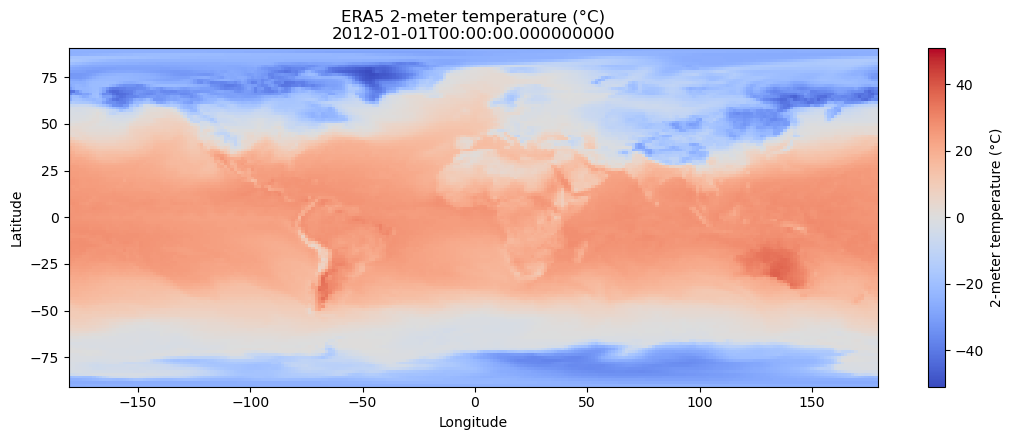

In [16]:
fig = plt.figure(figsize=(11, 4.5))

(t2m_sample - 273.15).plot(
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    cbar_kwargs={"label": "2-meter temperature (°C)"}
)

plt.title(f"ERA5 2-meter temperature (°C)\n{str(t2m_sample.time.values)}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

initial_map_path = FIGURES_DIR / "01_initial_era5_temperature_map.png"
fig.savefig(initial_map_path, dpi=200, bbox_inches="tight")
print("Saved figure:", initial_map_path)

plt.show()


The initial map shows the expected large-scale spatial organization of near-surface temperature, including the equator-to-pole gradient and land-ocean contrasts.

This confirms that the data can be interpreted as georeferenced climate fields: each time step is a two-dimensional latitude-longitude image, and the variable values correspond to physical temperature measurements in Kelvin.


## 3. Dataset characterization

This section characterizes the selected ERA5 2-meter temperature dataset in terms of its spatial grid, temporal sampling, physical meaning, units, and global statistical distribution.

This information is necessary before defining a learning problem, because the model input/output shapes, normalization strategy, and evaluation metrics all depend on the structure and physical scale of the data.


In [17]:
print("DataArray summary:")
print(t2m_era5)

print("\nDimensions:", t2m_era5.dims)
print("Shape     :", t2m_era5.shape)

print("\nCoordinates:")
for coord in t2m_era5.coords:
    print(f"- {coord}: shape {t2m_era5[coord].shape}")

print("\nAttributes:")
for key, value in t2m_era5.attrs.items():
    print(f"- {key}: {value}")

DataArray summary:
<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
[424332480 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

Dimensions: ('time', 'longitude', 'latitude')
Shape     : (14612, 240, 121)

Coordinates:
- latitude: shape (121,)
- time: shape (14612,)
- longitude: shape (240,)

Attributes:
- long_name: 2 metre temperature
- short_name: t2m
- units: K


In [18]:
lat_values = t2m_era5.latitude.values
lon_values = t2m_era5.longitude.values
time_values = t2m_era5.time.values

# Spatial resolution in degrees
lat_resolution = float(np.abs(np.diff(lat_values)).mean())
lon_resolution = float(np.abs(np.diff(lon_values)).mean())

# Temporal resolution in hours
time_diffs_hours = np.diff(time_values).astype("timedelta64[h]").astype(int)
temporal_resolution_hours = int(np.median(time_diffs_hours))

dataset_summary = {
    "n_time_steps": t2m_era5.sizes["time"],
    "n_latitude": t2m_era5.sizes["latitude"],
    "n_longitude": t2m_era5.sizes["longitude"],
    "latitude_resolution_deg": lat_resolution,
    "longitude_resolution_deg": lon_resolution,
    "temporal_resolution_hours": temporal_resolution_hours,
    "time_start": str(time_values[0]),
    "time_end": str(time_values[-1]),
    "latitude_min": float(lat_values.min()),
    "latitude_max": float(lat_values.max()),
    "longitude_min": float(lon_values.min()),
    "longitude_max": float(lon_values.max()),
}

pd.DataFrame.from_dict(dataset_summary, orient="index", columns=["value"])

,value
n_time_steps,14612
n_latitude,121
n_longitude,240
latitude_resolution_deg,1.5
longitude_resolution_deg,1.5
temporal_resolution_hours,6
time_start,2012-01-01T00:00:00.000000000
time_end,2021-12-31T18:00:00.000000000
latitude_min,-90.0
latitude_max,90.0


### Physical interpretation

The selected variable is `2m_temperature`.

It represents near-surface air temperature at 2 meters above the land, ocean, or ice surface. This is one of the most commonly used meteorological and climate variables because it directly relates to surface climate conditions, heat waves, cold spells, energy demand, ecological stress, and climate impact studies.

The variable is provided in Kelvin (K). For interpretation, it can be converted to degrees Celsius using:

$$
T_{^\circ C} = T_K - 273.15
$$

Each time step can be interpreted as a global georeferenced image on a latitude-longitude grid, where the pixel values are physical temperature values.


### Statistical strategy

The descriptive statistics are conceptually defined over the selected space-time data cube:

$$
T(t, \phi, \lambda)
$$

where $t$ is time, $\phi$ is latitude, and $\lambda$ is longitude.

The selected ERA5 subset contains 6-hourly global fields over the 2012–2021 period. A full computation over all time steps would require loading a large number of global maps from remote storage. To keep the workflow lightweight and stable in a local CPU-based environment, the statistics below are computed using a temporally stratified sample of 48 global fields distributed across the full selected period.

Each selected time step is a complete global map. Therefore, the full latitude-longitude grid is preserved, and only the temporal dimension is subsampled.

Two complementary statistical summaries are reported:

1. **Unweighted statistics**: each grid cell is treated equally. These are simple descriptive statistics over all sampled values.

2. **Area-weighted statistics**: each latitude band is weighted by the approximate physical area represented by its grid cells. Since the data are provided on a regular latitude-longitude grid, cells near the poles represent smaller surface areas than cells near the equator. A more physically meaningful global average therefore uses cosine-latitude weights:

$$
w(\phi) = \cos(\phi)
$$

where $\phi$ is latitude in radians.

The unweighted statistics are useful as a direct description of the numerical data array. The area-weighted statistics are more appropriate for physically interpreting global temperature summaries.


In [19]:
# Lightweight temporally stratified sample for statistical description.
# Each selected time step is a full global field.

N_STATS_SAMPLES = 48

sample_indices = np.linspace(
    0,
    t2m_era5.sizes["time"] - 1,
    N_STATS_SAMPLES,
    dtype=int
)

t2m_stats_sample = t2m_era5.isel(time=sample_indices).load()

print("Original shape :", t2m_era5.shape)
print("Sampled shape  :", t2m_stats_sample.shape)
print("Number of sampled global fields:", N_STATS_SAMPLES)
print("First sampled time:", str(t2m_stats_sample.time.values[0]))
print("Last sampled time :", str(t2m_stats_sample.time.values[-1]))

Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name weatherbench2: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authenticati

Original shape : (14612, 240, 121)
Sampled shape  : (48, 240, 121)
Number of sampled global fields: 48
First sampled time: 2012-01-01T00:00:00.000000000
Last sampled time : 2021-12-31T18:00:00.000000000


In [20]:
def weighted_quantile(values, quantiles, sample_weight):
    """
    Compute weighted quantiles for flattened arrays.

    Parameters
    ----------
    values : array-like
        Data values.
    quantiles : array-like
        Quantiles in [0, 1].
    sample_weight : array-like
        Weights associated with each value.

    Returns
    -------
    np.ndarray
        Weighted quantile values.
    """
    values = np.asarray(values).ravel()
    sample_weight = np.asarray(sample_weight).ravel()

    mask = np.isfinite(values) & np.isfinite(sample_weight) & (sample_weight > 0)
    values = values[mask]
    sample_weight = sample_weight[mask]

    sorter = np.argsort(values)
    values_sorted = values[sorter]
    weights_sorted = sample_weight[sorter]

    cumulative_weight = np.cumsum(weights_sorted)
    cumulative_weight = cumulative_weight / cumulative_weight[-1]

    return np.interp(quantiles, cumulative_weight, values_sorted)


# Values in Kelvin.
# Current dimensions are: time × longitude × latitude
t2m_values = t2m_stats_sample.values.astype(np.float64)

# ------------------------------------------------------------
# 1. Unweighted statistics
# ------------------------------------------------------------

unweighted_mean_K = np.nanmean(t2m_values)
unweighted_std_K = np.nanstd(t2m_values)
unweighted_min_K = np.nanmin(t2m_values)
unweighted_max_K = np.nanmax(t2m_values)

unweighted_percentiles_K = np.nanpercentile(
    t2m_values,
    [5, 25, 50, 75, 95]
)

# ------------------------------------------------------------
# 2. Area-weighted statistics using cosine-latitude weights
# ------------------------------------------------------------

latitudes = t2m_stats_sample.latitude.values
lat_weights = np.cos(np.deg2rad(latitudes))
lat_weights = np.clip(lat_weights, 0, None)

# Build weights with the same dimension order as t2m_stats_sample.
dims = t2m_stats_sample.dims
lat_axis = dims.index("latitude")

weight_shape = [1] * t2m_values.ndim
weight_shape[lat_axis] = len(latitudes)

weights = lat_weights.reshape(weight_shape)
weights_full = np.broadcast_to(weights, t2m_values.shape)

weighted_mean_K = np.average(t2m_values, weights=weights_full)

weighted_std_K = np.sqrt(
    np.average((t2m_values - weighted_mean_K) ** 2, weights=weights_full)
)

weighted_percentiles_K = weighted_quantile(
    t2m_values,
    [0.05, 0.25, 0.50, 0.75, 0.95],
    weights_full
)

# ------------------------------------------------------------
# Assemble comparison table
# ------------------------------------------------------------

stats_records = [
    {
        "statistic": "mean",
        "unweighted_K": unweighted_mean_K,
        "unweighted_C": unweighted_mean_K - 273.15,
        "area_weighted_K": weighted_mean_K,
        "area_weighted_C": weighted_mean_K - 273.15,
    },
    {
        "statistic": "std",
        "unweighted_K": unweighted_std_K,
        "unweighted_C": unweighted_std_K,  # std is a temperature difference
        "area_weighted_K": weighted_std_K,
        "area_weighted_C": weighted_std_K,  # std is a temperature difference
    },
    {
        "statistic": "min",
        "unweighted_K": unweighted_min_K,
        "unweighted_C": unweighted_min_K - 273.15,
        "area_weighted_K": np.nan,
        "area_weighted_C": np.nan,
    },
    {
        "statistic": "max",
        "unweighted_K": unweighted_max_K,
        "unweighted_C": unweighted_max_K - 273.15,
        "area_weighted_K": np.nan,
        "area_weighted_C": np.nan,
    },
    {
        "statistic": "percentile_05",
        "unweighted_K": unweighted_percentiles_K[0],
        "unweighted_C": unweighted_percentiles_K[0] - 273.15,
        "area_weighted_K": weighted_percentiles_K[0],
        "area_weighted_C": weighted_percentiles_K[0] - 273.15,
    },
    {
        "statistic": "percentile_25",
        "unweighted_K": unweighted_percentiles_K[1],
        "unweighted_C": unweighted_percentiles_K[1] - 273.15,
        "area_weighted_K": weighted_percentiles_K[1],
        "area_weighted_C": weighted_percentiles_K[1] - 273.15,
    },
    {
        "statistic": "percentile_50",
        "unweighted_K": unweighted_percentiles_K[2],
        "unweighted_C": unweighted_percentiles_K[2] - 273.15,
        "area_weighted_K": weighted_percentiles_K[2],
        "area_weighted_C": weighted_percentiles_K[2] - 273.15,
    },
    {
        "statistic": "percentile_75",
        "unweighted_K": unweighted_percentiles_K[3],
        "unweighted_C": unweighted_percentiles_K[3] - 273.15,
        "area_weighted_K": weighted_percentiles_K[3],
        "area_weighted_C": weighted_percentiles_K[3] - 273.15,
    },
    {
        "statistic": "percentile_95",
        "unweighted_K": unweighted_percentiles_K[4],
        "unweighted_C": unweighted_percentiles_K[4] - 273.15,
        "area_weighted_K": weighted_percentiles_K[4],
        "area_weighted_C": weighted_percentiles_K[4] - 273.15,
    },
]

stats_df = pd.DataFrame(stats_records).set_index("statistic")

# Save statistics immediately when this cell is executed.
stats_table_path = TABLES_DIR / "01_dataset_statistics_unweighted_and_area_weighted.csv"
stats_df.to_csv(stats_table_path)
print("Saved table:", stats_table_path)

stats_df


Saved table: /Users/edgarsteven/climate-residual-downscaling-unet/results/tables/01_dataset_statistics_unweighted_and_area_weighted.csv


,unweighted_K,unweighted_C,area_weighted_K,area_weighted_C
statistic,,,,
mean,278.698776,5.548776,287.745431,14.595431
std,21.178499,21.178499,15.252980,15.252980
min,197.009262,-76.140738,NaN,NaN
max,321.234222,48.084222,NaN,NaN
percentile_05,235.642667,-37.507333,255.488582,-17.661418
percentile_25,268.791191,-4.358809,280.434113,7.284113
percentile_50,283.380798,10.230798,292.877087,19.727087
percentile_75,296.527084,23.377084,298.933655,25.783655
percentile_95,301.108430,27.958430,301.664727,28.514727


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/02_temperature_distribution_unweighted_vs_area_weighted.png


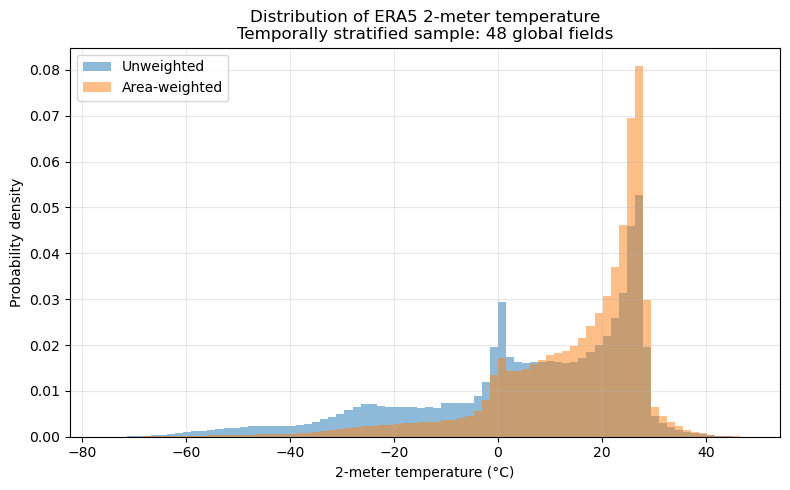

In [21]:
fig = plt.figure(figsize=(8, 5))

temperature_c = t2m_values.ravel() - 273.15
weights_relative = weights_full.ravel() / weights_full.sum()

plt.hist(
    temperature_c,
    bins=80,
    alpha=0.5,
    density=True,
    label="Unweighted"
)

plt.hist(
    temperature_c,
    bins=80,
    weights=weights_relative,
    alpha=0.5,
    density=True,
    label="Area-weighted"
)

plt.xlabel("2-meter temperature (°C)")
plt.ylabel("Probability density")
plt.title(
    "Distribution of ERA5 2-meter temperature\n"
    f"Temporally stratified sample: {N_STATS_SAMPLES} global fields"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

histogram_path = FIGURES_DIR / "02_temperature_distribution_unweighted_vs_area_weighted.png"
fig.savefig(histogram_path, dpi=200, bbox_inches="tight")
print("Saved figure:", histogram_path)

plt.show()


### Statistical interpretation

The table reports both unweighted and area-weighted statistics.

The unweighted statistics describe the numerical distribution of the sampled data array, treating each latitude-longitude grid cell equally. This is useful for understanding the values that the machine learning model directly sees as gridded input.

The area-weighted statistics provide a more physically meaningful global summary. On a regular latitude-longitude grid, high-latitude regions contain many grid cells but each cell represents a smaller physical surface area than cells near the equator. Cosine-latitude weighting corrects for this effect when computing global summaries.

The standard deviation is reported with the same numerical value in Kelvin and Celsius because it represents a temperature difference, not an absolute temperature.

The minimum and maximum values are sample-based extrema from the 48 selected global fields. They should not be interpreted as the absolute extrema of the full 2012–2021 6-hourly dataset.

For production-scale analysis, the same workflow can be applied to the full time series using chunked computation with `xarray`/`dask` or on an HPC system.


## 4. Coarsening the data and defining the inverse problem

The next step is to create a controlled downscaling problem.

Starting from the original ERA5 2-meter temperature field, a spatially smoothed version is generated using a Gaussian filter. The smoothing operation removes part of the small-scale spatial variability while preserving the large-scale temperature structure.

Importantly, this operation does **not** reduce the array size. The original and smoothed fields remain on the same latitude-longitude grid. What changes is the effective spatial resolution: the smoothed field contains less high-frequency spatial information.

Let:

$$
y_{\mathrm{HR}} = T(t, \phi, \lambda)
$$

be the original ERA5 field, and:

$$
y_{\mathrm{smooth}} = \mathcal{S}_{\sigma}(y_{\mathrm{HR}})
$$

be the Gaussian-smoothed field.

The missing spatial detail can be expressed as a residual:

$$
r = y_{\mathrm{HR}} - y_{\mathrm{smooth}}
$$

The reconstruction problem can then be written as:

$$
y_{\mathrm{HR}} = y_{\mathrm{smooth}} + r
$$

The learning task will be to approximate this residual using a Song U-Net model.


In [22]:
# For image-based modelling, it is convenient to use the dimension order:
# time × latitude × longitude.
#
# The statistical sample is reused here as a lightweight working dataset.
# It contains full global fields but only 48 time steps.

t2m_work = t2m_stats_sample.transpose("time", "latitude", "longitude")

print("Working dataset:")
print(t2m_work)

print("\nShape:", t2m_work.shape)
print("Dimensions:", t2m_work.dims)

Working dataset:
<xarray.DataArray '2m_temperature' (time: 48, latitude: 121, longitude: 240)> Size: 6MB
array([[[247.5613 , 247.58649, 247.60933, ..., 247.49359, 247.51613,
         247.53864],
        [246.48785, 246.52144, 246.53728, ..., 246.41907, 246.43484,
         246.45473],
        [248.18385, 248.29346, 248.45322, ..., 248.02388, 248.04158,
         248.09517],
        ...,
        [247.94714, 248.09679, 248.25433, ..., 247.58807, 247.6902 ,
         247.81139],
        [247.75345, 247.78972, 247.81508, ..., 247.64714, 247.6788 ,
         247.71362],
        [248.4725 , 248.47717, 248.48003, ..., 248.4468 , 248.4558 ,
         248.46484]],

       [[218.1964 , 218.17143, 218.14873, ..., 218.28632, 218.25497,
         218.22472],
        [220.67929, 220.70375, 220.72752, ..., 220.62285, 220.62067,
         220.65114],
        [227.17856, 227.12756, 227.12209, ..., 227.28706, 227.2802 ,
         227.23125],
...
        [259.2127 , 259.19208, 259.17413, ..., 259.2532 , 259.2548

In [23]:
# Gaussian smoothing parameter.
# This controls how strongly the field is smoothed in the spatial dimensions.
# A larger sigma removes more small-scale spatial variability.

GAUSSIAN_SIGMA = 2.0

# Convert to NumPy.
# Shape: time × latitude × longitude
t2m_hr_values = t2m_work.values.astype(np.float32)

# Apply Gaussian smoothing only in the spatial dimensions.
# sigma = (0, sigma_lat, sigma_lon)
#
# mode:
# - time: nearest, because we do not smooth over time
# - latitude: nearest, simple boundary treatment at poles
# - longitude: wrap, because longitude is periodic
t2m_smooth_values = gaussian_filter(
    t2m_hr_values,
    sigma=(0, GAUSSIAN_SIGMA, GAUSSIAN_SIGMA),
    mode=("nearest", "nearest", "wrap")
)

# Convert back to xarray DataArray with the same coordinates.
t2m_smooth = xr.DataArray(
    t2m_smooth_values,
    dims=t2m_work.dims,
    coords=t2m_work.coords,
    name="2m_temperature_smoothed",
    attrs={
        "long_name": "Gaussian-smoothed 2 metre temperature",
        "units": "K",
        "gaussian_sigma": GAUSSIAN_SIGMA,
    }
)

# Residual: information removed by smoothing.
t2m_residual = t2m_work - t2m_smooth
t2m_residual.name = "2m_temperature_residual"

print("Original field shape :", t2m_work.shape)
print("Smoothed field shape :", t2m_smooth.shape)
print("Residual field shape :", t2m_residual.shape)

Original field shape : (48, 121, 240)
Smoothed field shape : (48, 121, 240)
Residual field shape : (48, 121, 240)


 The original, smoothed, and residual fields all have the same grid shape.

This is important: the Gaussian filter creates a degraded version of the data in terms of spatial detail, but it does not change the number of latitude-longitude grid cells.

Therefore, the residual can be computed directly by subtracting the smoothed field from the original field at the same grid points.


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/03_coarsening_and_residual_definition.png


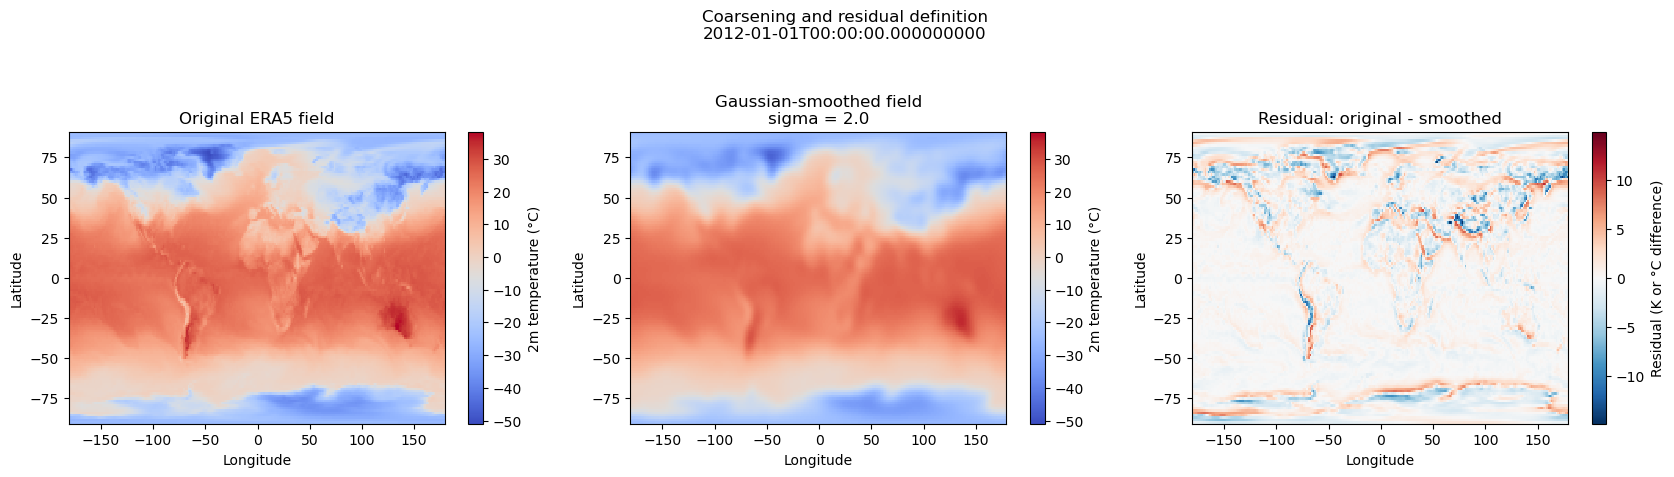

In [24]:
# Select one sampled global field for visual inspection.
plot_index = 0

hr_plot = t2m_work.isel(time=plot_index)
smooth_plot = t2m_smooth.isel(time=plot_index)
residual_plot = t2m_residual.isel(time=plot_index)

plot_time = str(hr_plot.time.values)

# Convert absolute temperatures to Celsius for interpretability.
hr_c = hr_plot - 273.15
smooth_c = smooth_plot - 273.15

# Residual is a temperature difference, so K and °C have the same numerical scale.
residual_c = residual_plot

vmin = float(min(hr_c.min(), smooth_c.min()))
vmax = float(max(hr_c.max(), smooth_c.max()))

res_abs_max = float(np.nanmax(np.abs(residual_c.values)))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

hr_c.plot(
    ax=axes[0],
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={"label": "2m temperature (°C)"}
)
axes[0].set_title("Original ERA5 field")

smooth_c.plot(
    ax=axes[1],
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={"label": "2m temperature (°C)"}
)
axes[1].set_title(f"Gaussian-smoothed field\nsigma = {GAUSSIAN_SIGMA}")

residual_c.plot(
    ax=axes[2],
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-res_abs_max,
    vmax=res_abs_max,
    cbar_kwargs={"label": "Residual (K or °C difference)"}
)
axes[2].set_title("Residual: original - smoothed")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle(f"Coarsening and residual definition\n{plot_time}", y=1.05)
plt.tight_layout()

coarsening_path = FIGURES_DIR / "03_coarsening_and_residual_definition.png"
fig.savefig(coarsening_path, dpi=200, bbox_inches="tight")
print("Saved figure:", coarsening_path)

plt.show()


In [25]:
residual_values = t2m_residual.values

residual_summary = {
    "residual_mean": np.nanmean(residual_values),
    "residual_std": np.nanstd(residual_values),
    "residual_min": np.nanmin(residual_values),
    "residual_max": np.nanmax(residual_values),
    "residual_mae": np.nanmean(np.abs(residual_values)),
    "residual_p05": np.nanpercentile(residual_values, 5),
    "residual_p50": np.nanpercentile(residual_values, 50),
    "residual_p95": np.nanpercentile(residual_values, 95),
}

residual_df = pd.DataFrame.from_dict(
    residual_summary,
    orient="index",
    columns=["K or °C difference"]
)

residual_table_path = TABLES_DIR / "02_residual_statistics.csv"
residual_df.to_csv(residual_table_path)
print("Saved table:", residual_table_path)

residual_df


Saved table: /Users/edgarsteven/climate-residual-downscaling-unet/results/tables/02_residual_statistics.csv


,K or °C difference
residual_mean,0.008397
residual_std,1.898616
residual_min,-23.101913
residual_max,15.374557
residual_mae,1.174584
residual_p05,-3.197558
residual_p50,0.062866
residual_p95,2.927704


The residual field contains the spatial information removed by Gaussian smoothing.

A near-zero residual would indicate that the smoothed field is close to the original field at that grid cell. Larger positive or negative residuals indicate locations where smoothing removed local spatial structure.

This residual formulation is useful for learning because the model does not need to reconstruct the full temperature field from scratch. The large-scale temperature pattern is already present in the smoothed input. The neural network can focus on estimating the missing spatial correction.

This leads to the proposed learning formulation:

$$
\hat{r} = G_{\theta}(y_{\mathrm{smooth}})
$$

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}} + \hat{r}
$$

where $G_{\theta}$ is the Song U-Net model.


## 5. Learning formulation and normalization

The learning problem is formulated as a supervised image-to-image regression task.

For each sampled time step, the model receives the smoothed temperature field as input and learns to predict the residual removed by the Gaussian filter.

The input is:

$$
x = y_{\mathrm{smooth}}
$$

The target is:

$$
r = y_{\mathrm{HR}} - y_{\mathrm{smooth}}
$$

The final reconstructed field is obtained as:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}} + \hat{r}
$$

This residual formulation is useful because the smoothed field already contains the large-scale temperature structure. The neural network can therefore focus on learning the missing spatial correction rather than reconstructing the full climate field from scratch.

The temporal split follows the logic of the technical exercise:

- 2012–2019 for training,
- 2020 for validation,
- 2021 for testing.

Because this notebook is designed as a lightweight local workflow, the split is applied to the 48 temporally stratified global fields selected earlier.


In [26]:
# Temporal split using the sampled global fields.
# The sample preserves the full global grid but contains only 48 time steps.

time_index = pd.DatetimeIndex(t2m_work.time.values)
years = time_index.year

train_idx = np.where((years >= 2012) & (years <= 2019))[0]
val_idx = np.where(years == 2020)[0]
test_idx = np.where(years == 2021)[0]

print("Number of sampled fields:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nTrain years:", sorted(set(years[train_idx])))
print("Validation years:", sorted(set(years[val_idx])))
print("Test years:", sorted(set(years[test_idx])))

Number of sampled fields:
Train: 38
Validation: 5
Test: 5

Train years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Validation years: [2020]
Test years: [2021]


In [27]:
# Inputs and targets.
# x_raw: smoothed temperature field in Kelvin.
# r_raw: residual field in Kelvin difference.
# y_hr_raw: original ERA5 temperature field in Kelvin.

x_raw = t2m_smooth
r_raw = t2m_residual
y_hr_raw = t2m_work

# Split xarray objects by temporal indices.
x_train = x_raw.isel(time=train_idx)
r_train = r_raw.isel(time=train_idx)
y_train_hr = y_hr_raw.isel(time=train_idx)

x_val = x_raw.isel(time=val_idx)
r_val = r_raw.isel(time=val_idx)
y_val_hr = y_hr_raw.isel(time=val_idx)

x_test = x_raw.isel(time=test_idx)
r_test = r_raw.isel(time=test_idx)
y_test_hr = y_hr_raw.isel(time=test_idx)

print("Train input shape :", x_train.shape)
print("Train target shape:", r_train.shape)

print("Validation input shape :", x_val.shape)
print("Validation target shape:", r_val.shape)

print("Test input shape :", x_test.shape)
print("Test target shape:", r_test.shape)

Train input shape : (38, 121, 240)
Train target shape: (38, 121, 240)
Validation input shape : (5, 121, 240)
Validation target shape: (5, 121, 240)
Test input shape : (5, 121, 240)
Test target shape: (5, 121, 240)


### Normalization strategy

The smoothed temperature field and the residual field have different physical scales.

The smoothed field is an absolute temperature field in Kelvin, typically around hundreds of Kelvin. The residual is a temperature difference, usually much smaller and centered near zero.

For this reason, the input and target are normalized separately:

$$
x_{\mathrm{norm}} = \frac{x - \mu_x}{\sigma_x}
$$

$$
r_{\mathrm{norm}} = \frac{r - \mu_r}{\sigma_r}
$$

The normalization parameters are estimated from the training period only. This avoids information leakage from validation and test data into the training process.


In [28]:
EPS = 1e-6

# Training statistics only.
x_mean = float(x_train.mean().values)
x_std = float(x_train.std().values)

r_mean = float(r_train.mean().values)
r_std = float(r_train.std().values)

print("Input normalization statistics:")
print("x_mean:", x_mean)
print("x_std :", x_std)

print("\nResidual normalization statistics:")
print("r_mean:", r_mean)
print("r_std :", r_std)

Input normalization statistics:
x_mean: 278.71441650390625
x_std : 20.829090118408203

Residual normalization statistics:
r_mean: 0.008802138268947601
r_std : 1.8953582048416138


In [29]:
def normalize_field(da, mean, std):
    return (da - mean) / (std + EPS)


def denormalize_field(da_norm, mean, std):
    return da_norm * (std + EPS) + mean


x_train_norm = normalize_field(x_train, x_mean, x_std)
x_val_norm = normalize_field(x_val, x_mean, x_std)
x_test_norm = normalize_field(x_test, x_mean, x_std)

r_train_norm = normalize_field(r_train, r_mean, r_std)
r_val_norm = normalize_field(r_val, r_mean, r_std)
r_test_norm = normalize_field(r_test, r_mean, r_std)

print("Normalized train input mean:", float(x_train_norm.mean().values))
print("Normalized train input std :", float(x_train_norm.std().values))

print("Normalized train residual mean:", float(r_train_norm.mean().values))
print("Normalized train residual std :", float(r_train_norm.std().values))

Normalized train input mean: 3.181403371854685e-07
Normalized train input std : 0.9999998807907104
Normalized train residual mean: -4.1482137169701616e-10
Normalized train residual std : 0.9999995827674866


In [30]:
class ResidualDownscalingDataset(Dataset):
    """
    PyTorch dataset for residual-based climate downscaling.

    Each sample contains:
    - normalized smoothed input field,
    - normalized residual target,
    - raw smoothed field,
    - raw high-resolution field.

    The raw fields are kept for later reconstruction and evaluation.
    """

    def __init__(self, x_norm, r_norm, x_raw, y_hr_raw):
        self.x_norm = np.ascontiguousarray(x_norm.values.astype(np.float32))
        self.r_norm = np.ascontiguousarray(r_norm.values.astype(np.float32))
        self.x_raw = np.ascontiguousarray(x_raw.values.astype(np.float32))
        self.y_hr_raw = np.ascontiguousarray(y_hr_raw.values.astype(np.float32))

    def __len__(self):
        return self.x_norm.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.x_norm[idx][None, :, :])
        r = torch.from_numpy(self.r_norm[idx][None, :, :])
        x_raw = torch.from_numpy(self.x_raw[idx][None, :, :])
        y_hr = torch.from_numpy(self.y_hr_raw[idx][None, :, :])

        return {
            "x": x,
            "residual": r,
            "x_raw": x_raw,
            "y_hr": y_hr,
        }

In [31]:
BATCH_SIZE = 4

train_dataset = ResidualDownscalingDataset(
    x_train_norm,
    r_train_norm,
    x_train,
    y_train_hr
)

val_dataset = ResidualDownscalingDataset(
    x_val_norm,
    r_val_norm,
    x_val,
    y_val_hr
)

test_dataset = ResidualDownscalingDataset(
    x_test_norm,
    r_test_norm,
    x_test,
    y_test_hr
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 10
Validation batches: 2
Test batches: 2


In [32]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(f"{key}: {tuple(value.shape)}")

x: (4, 1, 121, 240)
residual: (4, 1, 121, 240)
x_raw: (4, 1, 121, 240)
y_hr: (4, 1, 121, 240)


At this point, the learning dataset is ready.

Each training sample is a georeferenced global temperature field represented as a tensor with shape:

$$
1 \times 121 \times 240
$$

where the first dimension is the channel dimension.

The model input is the normalized smoothed temperature field, and the target is the normalized residual. During inference, the predicted residual will be denormalized and added back to the original smoothed field to reconstruct the high-resolution temperature field.

This prepares the workflow for the Song U-Net architecture.


## 6. Song U-Net architecture

The neural architecture used in this workflow is the `SongUNet` implementation available in `IPSL_AID.networks`.

The model is used as a deterministic image-to-image regression network, without diffusion preconditioning. In this setting, the network receives a normalized smoothed temperature field and predicts the normalized residual field.

$$
\hat{r}_{\mathrm{norm}} = G_{\theta}(x_{\mathrm{norm}})
$$

where $G_{\theta}$ is the Song U-Net.

The ERA5 grid used here has shape:

$$
121 \times 240
$$

The latitude dimension is odd. Encoder-decoder architectures such as U-Nets repeatedly downsample and upsample spatial dimensions, which can create shape mismatches in skip connections when one dimension is not divisible by powers of two.

To avoid modifying the original IPSL-AID implementation, a lightweight wrapper is used:

1. Pad the input from $121 \times 240$ to $128 \times 240$.
2. Apply `SongUNet`.
3. Crop the output back to $121 \times 240$.

This preserves the original ERA5 grid in the final prediction while making the internal U-Net operations shape-compatible.


In [33]:
class PaddedSongUNet(nn.Module):
    """
    Wrapper around IPSL-AID SongUNet for ERA5 fields with shape 121 x 240.

    The latitude dimension is odd, which can produce size mismatches inside
    encoder-decoder U-Net architectures with skip connections.

    This wrapper:
    1. Pads the input to a U-Net-friendly resolution.
    2. Applies SongUNet.
    3. Crops the output back to the original resolution.
    """

    def __init__(
        self,
        original_resolution=(121, 240),
        padded_resolution=(128, 240),
        in_channels=1,
        out_channels=1,
        model_channels=16,
        channel_mult=(1, 2, 2),
        num_blocks=1,
        dropout=0.0,
    ):
        super().__init__()

        self.original_resolution = original_resolution
        self.padded_resolution = padded_resolution

        self.net = SongUNet(
            img_resolution=padded_resolution,
            in_channels=in_channels,
            out_channels=out_channels,
            label_dim=0,
            augment_dim=0,
            model_channels=model_channels,
            channel_mult=list(channel_mult),
            num_blocks=num_blocks,
            attn_resolutions=[],
            dropout=dropout,
            diffusion_model=False,
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Tensor with shape [batch, channels, latitude, longitude].

        Returns
        -------
        torch.Tensor
            Tensor with shape [batch, channels, latitude, longitude],
            cropped back to the original input size.
        """
        h, w = x.shape[-2:]
        target_h, target_w = self.padded_resolution

        pad_h = target_h - h
        pad_w = target_w - w

        if pad_h < 0 or pad_w < 0:
            raise ValueError(
                f"Input resolution {(h, w)} is larger than padded resolution "
                f"{self.padded_resolution}."
            )

        # Padding order for 2D tensors is: left, right, top, bottom.
        x_pad = F.pad(
            x,
            pad=(0, pad_w, 0, pad_h),
            mode="replicate"
        )

        y_pad = self.net(x_pad)

        # Crop back to the original resolution.
        y = y_pad[..., :h, :w]

        return y

In [34]:
model = PaddedSongUNet(
    original_resolution=(121, 240),
    padded_resolution=(128, 240),
    in_channels=1,
    out_channels=1,
    model_channels=16,
    channel_mult=(1, 2, 2),
    num_blocks=1,
    dropout=0.0,
).to(device)

model

PaddedSongUNet(
  (net): SongUNet(
    (map_layer0): Linear()
    (map_layer1): Linear()
    (enc): ModuleDict(
      (128x240_conv): Conv2d()
      (128x240_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (64x120_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
        (skip): Conv2d()
      )
      (64x120_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
        (skip): Conv2d()
      )
      (32x60_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
        (skip): Conv2d()
      )
      (32x60_block0): UNetBlock(
        (norm0): GroupNorm()
        

In [35]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


n_params = count_trainable_parameters(model)

print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 308,545


In [36]:
batch = next(iter(train_loader))

x_batch = batch["x"].to(device)
r_batch = batch["residual"].to(device)

with torch.no_grad():
    r_pred_batch = model(x_batch)

print("Input batch shape          :", tuple(x_batch.shape))
print("Target residual shape      :", tuple(r_batch.shape))
print("Predicted residual shape   :", tuple(r_pred_batch.shape))

Input batch shape          : (4, 1, 121, 240)
Target residual shape      : (4, 1, 121, 240)
Predicted residual shape   : (4, 1, 121, 240)


The architecture is now compatible with the learning problem.

The model takes a normalized smoothed temperature field and returns a normalized residual prediction with the same spatial shape as the target.

The padding/cropping wrapper is only a technical adaptation to handle the odd latitude dimension of the ERA5 grid. The underlying neural architecture remains the `SongUNet` implementation from IPSL-AID, used without diffusion preconditioning.

The next step is to define a loss function and a lightweight training loop.


## 7. Loss function and training workflow

The model is trained to predict the normalized residual field:

$$
\hat{r}_{\mathrm{norm}} = G_{\theta}(x_{\mathrm{norm}})
$$

The target is the normalized residual:

$$
r_{\mathrm{norm}} = \frac{r - \mu_r}{\sigma_r}
$$

A pixel-wise regression loss is appropriate because the output is a continuous climate field. Here, a Smooth L1 loss is used. It behaves similarly to mean squared error for small errors but is less sensitive to large residuals or localized extremes.

The training objective is:

$$
\mathcal{L}(\theta) =
\mathrm{SmoothL1}
\left(
G_{\theta}(x_{\mathrm{norm}}),
r_{\mathrm{norm}}
\right)
$$

This lightweight training loop is intended to demonstrate the architecture and workflow on a local CPU-based environment.


In [37]:
# Training configuration.
# This is intentionally lightweight for local CPU execution.

NUM_EPOCHS = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

# For very quick debugging, set these to small integers.
# For example: MAX_TRAIN_BATCHES_PER_EPOCH = 2
# Use None to run over all available batches.
MAX_TRAIN_BATCHES_PER_EPOCH = None
MAX_VAL_BATCHES = None

criterion = nn.SmoothL1Loss(beta=0.5)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Loss function:", criterion)
print("Optimizer    :", optimizer.__class__.__name__)
print("Epochs       :", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Device       :", device)

Loss function: SmoothL1Loss()
Optimizer    : AdamW
Epochs       : 3
Learning rate: 0.001
Device       : cpu


In [38]:
def run_epoch(
    model,
    dataloader,
    criterion,
    optimizer=None,
    device="cpu",
    max_batches=None,
):
    """
    Run one training or evaluation epoch.

    If optimizer is provided, the model is trained.
    If optimizer is None, the model is evaluated without gradient updates.
    """
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    for batch_idx, batch in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = batch["x"].to(device)
        target_residual = batch["residual"].to(device)

        with torch.set_grad_enabled(is_training):
            pred_residual = model(x)
            loss = criterion(pred_residual, target_residual)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    mean_loss = total_loss / max(total_samples, 1)

    return mean_loss

In [39]:
import time

history = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = run_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        max_batches=MAX_TRAIN_BATCHES_PER_EPOCH,
    )

    val_loss = run_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device,
        max_batches=MAX_VAL_BATCHES,
    )

    epoch_time = time.time() - epoch_start

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "epoch_time_seconds": epoch_time,
        }
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.6f} | "
        f"val loss: {val_loss:.6f} | "
        f"time: {epoch_time:.1f}s"
    )

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.1f}s")

history_df = pd.DataFrame(history)

training_history_table_path = TABLES_DIR / "03_training_history.csv"
history_df.to_csv(training_history_table_path, index=False)
print("Saved table:", training_history_table_path)

checkpoint_path = CHECKPOINTS_DIR / "songunet_residual_downscaling_state.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "normalization": {
            "x_mean": x_mean,
            "x_std": x_std,
            "r_mean": r_mean,
            "r_std": r_std,
            "eps": EPS,
        },
        "config": {
            "gaussian_sigma": GAUSSIAN_SIGMA,
            "num_epochs": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
        },
    },
    checkpoint_path,
)
print("Saved checkpoint:", checkpoint_path)

history_df


Epoch 01/3 | train loss: 0.421005 | val loss: 0.380622 | time: 11.6s
Epoch 02/3 | train loss: 0.344518 | val loss: 0.311691 | time: 11.2s
Epoch 03/3 | train loss: 0.289118 | val loss: 0.268558 | time: 11.2s

Total training time: 34.0s
Saved table: /Users/edgarsteven/climate-residual-downscaling-unet/results/tables/03_training_history.csv
Saved checkpoint: /Users/edgarsteven/climate-residual-downscaling-unet/results/checkpoints/songunet_residual_downscaling_state.pt


,epoch,train_loss,val_loss,epoch_time_seconds
0,1,0.421005,0.380622,11.636025
1,2,0.344518,0.311691,11.152512
2,3,0.289118,0.268558,11.191900


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/04_training_history.png


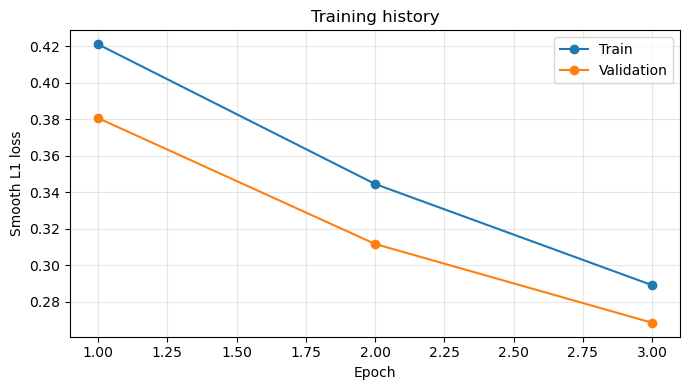

In [40]:
fig = plt.figure(figsize=(7, 4))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 loss")
plt.title("Training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

training_history_fig_path = FIGURES_DIR / "04_training_history.png"
fig.savefig(training_history_fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", training_history_fig_path)

plt.show()


In [41]:
def compute_zero_residual_baseline_loss(
    dataloader,
    criterion,
    r_mean,
    r_std,
    device="cpu",
):
    """
    Compute the loss of a zero-residual baseline.

    In raw physical space, this baseline predicts:
        r_pred = 0

    In normalized residual space:
        r_pred_norm = (0 - r_mean) / r_std
    """
    model_baseline_value = (0.0 - r_mean) / (r_std + EPS)

    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        target_residual = batch["residual"].to(device)

        pred_residual = torch.full_like(
            target_residual,
            fill_value=model_baseline_value
        )

        loss = criterion(pred_residual, target_residual)

        batch_size = target_residual.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / max(total_samples, 1)


baseline_val_loss = compute_zero_residual_baseline_loss(
    dataloader=val_loader,
    criterion=criterion,
    r_mean=r_mean,
    r_std=r_std,
    device=device,
)

final_val_loss = history_df["val_loss"].iloc[-1]

print("Validation loss:")
print(f"Zero-residual baseline: {baseline_val_loss:.6f}")
print(f"Trained Song U-Net    : {final_val_loss:.6f}")

Validation loss:
Zero-residual baseline: 0.444894
Trained Song U-Net    : 0.268558


The zero-residual baseline corresponds to using the smoothed field directly as the reconstruction:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}}
$$

The trained Song U-Net instead predicts a correction term:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}} + \hat{r}
$$

At this stage, the validation loss is only a lightweight diagnostic. Because the model is trained on a small temporally sampled dataset and on a local CPU environment, the objective is not to maximize performance, but to demonstrate a coherent residual-learning workflow.

A more complete experiment would train on the full temporal dataset, use larger model capacity, tune hyperparameters, and evaluate across seasons and regions.


## 8. Reconstruction and evaluation

The trained model predicts a normalized residual field. To evaluate the result in physical units, the predicted residual is first denormalized:

$$
\hat{r} = \hat{r}_{\mathrm{norm}} \sigma_r + \mu_r
$$

The reconstructed high-resolution field is then obtained by adding the predicted residual to the smoothed input field:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}} + \hat{r}
$$

The natural baseline is the smoothed field itself:

$$
\hat{y}_{\mathrm{baseline}} = y_{\mathrm{smooth}}
$$

The evaluation compares:

1. the original ERA5 field,
2. the smoothed baseline,
3. the Song U-Net reconstruction.

Metrics are computed in physical temperature units.


In [42]:
def denormalize_residual_tensor(residual_norm, r_mean, r_std):
    """
    Convert normalized residual predictions back to physical units.
    """
    return residual_norm * (r_std + EPS) + r_mean


def compute_metrics(pred, target):
    """
    Compute basic regression metrics in physical units.

    Parameters
    ----------
    pred : torch.Tensor
        Predicted field.
    target : torch.Tensor
        Reference field.

    Returns
    -------
    dict
        MAE, RMSE, and bias.
    """
    error = pred - target

    mae = torch.mean(torch.abs(error)).item()
    rmse = torch.sqrt(torch.mean(error ** 2)).item()
    bias = torch.mean(error).item()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
    }

In [43]:
model.eval()

baseline_metrics_list = []
model_metrics_list = []

all_examples = []

with torch.no_grad():
    for batch in test_loader:
        x_norm = batch["x"].to(device)
        x_raw = batch["x_raw"].to(device)      # smoothed field in K
        y_hr = batch["y_hr"].to(device)        # original ERA5 field in K

        # Predict normalized residual.
        pred_residual_norm = model(x_norm)

        # Denormalize residual to physical units.
        pred_residual = denormalize_residual_tensor(
            pred_residual_norm,
            r_mean=r_mean,
            r_std=r_std
        )

        # Reconstruct high-resolution field.
        y_pred = x_raw + pred_residual

        # Baseline: no residual correction.
        y_baseline = x_raw

        baseline_metrics_list.append(
            compute_metrics(y_baseline, y_hr)
        )

        model_metrics_list.append(
            compute_metrics(y_pred, y_hr)
        )

        # Store one batch for visualization.
        if len(all_examples) == 0:
            all_examples.append(
                {
                    "x_raw": x_raw.cpu(),
                    "y_hr": y_hr.cpu(),
                    "pred_residual": pred_residual.cpu(),
                    "y_pred": y_pred.cpu(),
                    "y_baseline": y_baseline.cpu(),
                }
            )


baseline_metrics_df = pd.DataFrame(baseline_metrics_list)
model_metrics_df = pd.DataFrame(model_metrics_list)

metrics_summary = pd.DataFrame(
    {
        "Smoothed baseline": baseline_metrics_df.mean(),
        "Song U-Net reconstruction": model_metrics_df.mean(),
    }
)

metrics_table_path = TABLES_DIR / "04_test_metrics_summary.csv"
metrics_summary.to_csv(metrics_table_path)
print("Saved table:", metrics_table_path)

metrics_summary


Saved table: /Users/edgarsteven/climate-residual-downscaling-unet/results/tables/04_test_metrics_summary.csv


,Smoothed baseline,Song U-Net reconstruction
MAE,1.201730,0.823746
RMSE,1.925293,1.361769
Bias,-0.003982,-0.044126


In [44]:
relative_improvement = (
    (metrics_summary["Smoothed baseline"] - metrics_summary["Song U-Net reconstruction"])
    / metrics_summary["Smoothed baseline"]
) * 100

relative_improvement_df = relative_improvement.to_frame(
    name="Relative improvement (%)"
)

relative_improvement_table_path = TABLES_DIR / "05_relative_improvement.csv"
relative_improvement_df.to_csv(relative_improvement_table_path)
print("Saved table:", relative_improvement_table_path)

relative_improvement_df


Saved table: /Users/edgarsteven/climate-residual-downscaling-unet/results/tables/05_relative_improvement.csv


,Relative improvement (%)
MAE,31.453370
RMSE,29.269518
Bias,-1008.069247


The baseline corresponds to assuming that no residual correction is needed. In other words, it uses the smoothed field directly as the final reconstruction.

The Song U-Net reconstruction improves on the baseline only if the predicted residual reduces the error with respect to the original ERA5 field. Since this is a lightweight local experiment trained on a very small temporal sample, the metrics should be interpreted as a workflow diagnostic rather than as a final performance benchmark.


In [45]:
example = all_examples[0]

sample_id = 0

hr = example["y_hr"][sample_id, 0].numpy()
baseline = example["y_baseline"][sample_id, 0].numpy()
prediction = example["y_pred"][sample_id, 0].numpy()

true_residual = hr - baseline
pred_residual = example["pred_residual"][sample_id, 0].numpy()

baseline_error = baseline - hr
prediction_error = prediction - hr

# Convert absolute temperatures to Celsius.
hr_c = hr - 273.15
baseline_c = baseline - 273.15
prediction_c = prediction - 273.15

# Residuals and errors are temperature differences, same numerical scale in K and °C.
true_residual_c = true_residual
pred_residual_c = pred_residual
baseline_error_c = baseline_error
prediction_error_c = prediction_error

print("Example field shape:", hr.shape)

Example field shape: (121, 240)


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/05_reconstruction_comparison.png


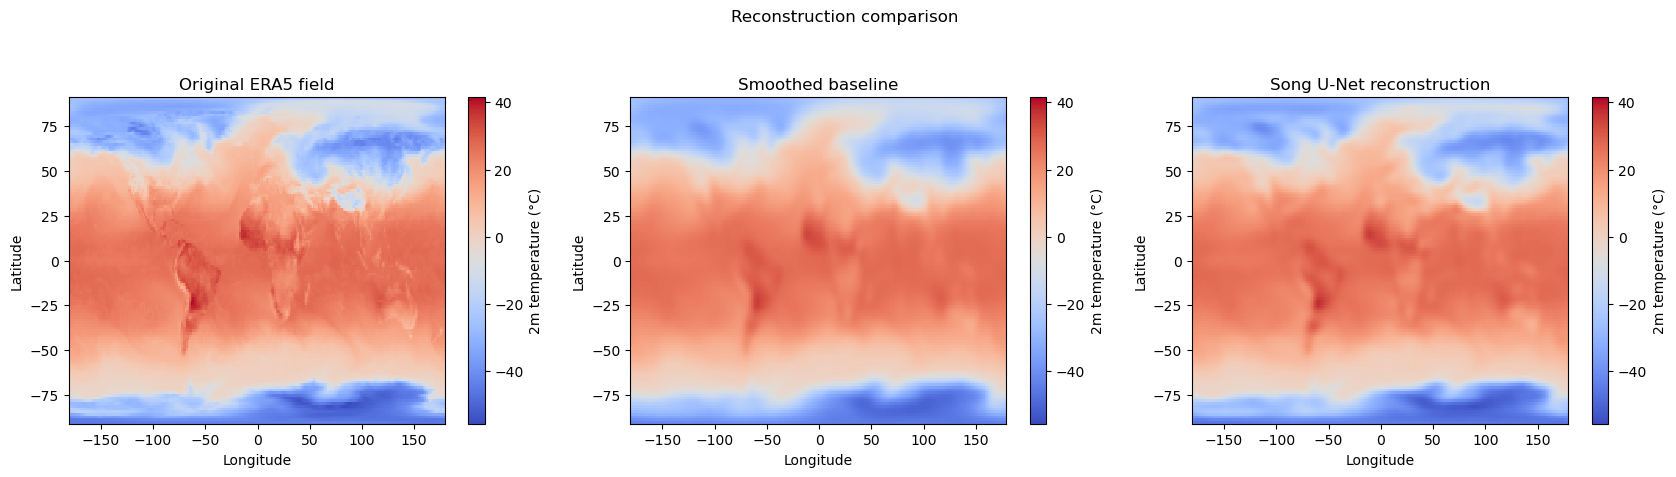

In [46]:
lon = t2m_work.longitude.values
lat = t2m_work.latitude.values

temp_vmin = float(np.nanmin([hr_c.min(), baseline_c.min(), prediction_c.min()]))
temp_vmax = float(np.nanmax([hr_c.max(), baseline_c.max(), prediction_c.max()]))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

im0 = axes[0].pcolormesh(lon, lat, hr_c, shading="auto", cmap="coolwarm", vmin=temp_vmin, vmax=temp_vmax)
axes[0].set_title("Original ERA5 field")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="2m temperature (°C)")

im1 = axes[1].pcolormesh(lon, lat, baseline_c, shading="auto", cmap="coolwarm", vmin=temp_vmin, vmax=temp_vmax)
axes[1].set_title("Smoothed baseline")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="2m temperature (°C)")

im2 = axes[2].pcolormesh(lon, lat, prediction_c, shading="auto", cmap="coolwarm", vmin=temp_vmin, vmax=temp_vmax)
axes[2].set_title("Song U-Net reconstruction")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
plt.colorbar(im2, ax=axes[2], label="2m temperature (°C)")

fig.suptitle("Reconstruction comparison", y=1.05)
plt.tight_layout()

reconstruction_fig_path = FIGURES_DIR / "05_reconstruction_comparison.png"
fig.savefig(reconstruction_fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", reconstruction_fig_path)

plt.show()


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/06_residual_comparison.png


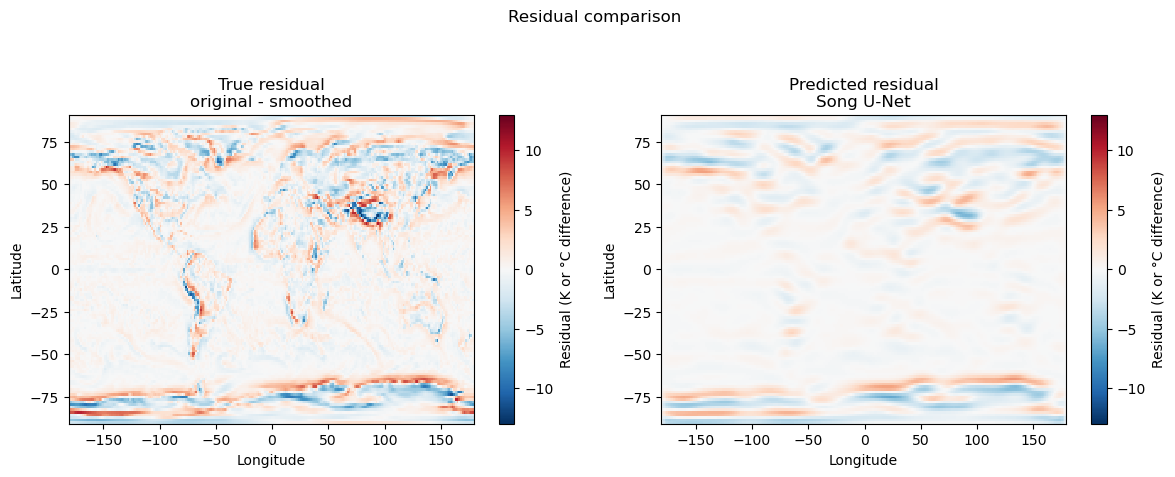

In [47]:
residual_abs_max = float(
    np.nanmax(
        np.abs(
            np.concatenate(
                [
                    true_residual_c.ravel(),
                    pred_residual_c.ravel(),
                ]
            )
        )
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].pcolormesh(
    lon,
    lat,
    true_residual_c,
    shading="auto",
    cmap="RdBu_r",
    vmin=-residual_abs_max,
    vmax=residual_abs_max,
)
axes[0].set_title("True residual\noriginal - smoothed")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="Residual (K or °C difference)")

im1 = axes[1].pcolormesh(
    lon,
    lat,
    pred_residual_c,
    shading="auto",
    cmap="RdBu_r",
    vmin=-residual_abs_max,
    vmax=residual_abs_max,
)
axes[1].set_title("Predicted residual\nSong U-Net")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="Residual (K or °C difference)")

fig.suptitle("Residual comparison", y=1.05)
plt.tight_layout()

residual_fig_path = FIGURES_DIR / "06_residual_comparison.png"
fig.savefig(residual_fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", residual_fig_path)

plt.show()


Saved figure: /Users/edgarsteven/climate-residual-downscaling-unet/results/figures/07_error_comparison.png


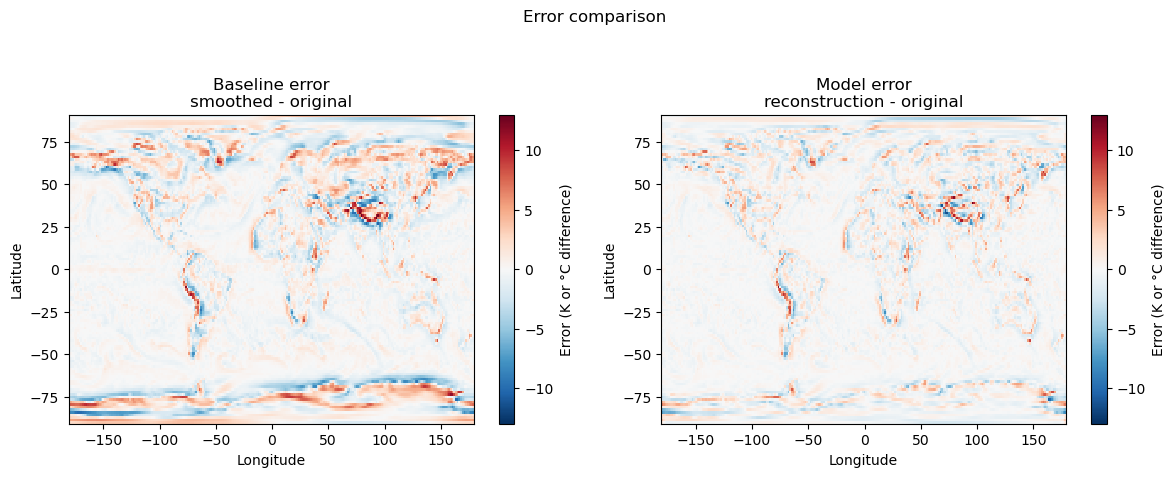

In [48]:
error_abs_max = float(
    np.nanmax(
        np.abs(
            np.concatenate(
                [
                    baseline_error_c.ravel(),
                    prediction_error_c.ravel(),
                ]
            )
        )
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].pcolormesh(
    lon,
    lat,
    baseline_error_c,
    shading="auto",
    cmap="RdBu_r",
    vmin=-error_abs_max,
    vmax=error_abs_max,
)
axes[0].set_title("Baseline error\nsmoothed - original")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="Error (K or °C difference)")

im1 = axes[1].pcolormesh(
    lon,
    lat,
    prediction_error_c,
    shading="auto",
    cmap="RdBu_r",
    vmin=-error_abs_max,
    vmax=error_abs_max,
)
axes[1].set_title("Model error\nreconstruction - original")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="Error (K or °C difference)")

fig.suptitle("Error comparison", y=1.05)
plt.tight_layout()

error_fig_path = FIGURES_DIR / "07_error_comparison.png"
fig.savefig(error_fig_path, dpi=200, bbox_inches="tight")
print("Saved figure:", error_fig_path)

plt.show()


The evaluation compares the smoothed baseline and the Song U-Net reconstruction against the original ERA5 field.

The residual maps are particularly important because they show what the model is trying to learn: the spatial correction removed by the Gaussian filter. If the predicted residual resembles the true residual, the reconstruction can recover part of the missing spatial detail.

The error maps provide a direct diagnostic of whether the learned residual reduces reconstruction error compared with the smoothed baseline.

Because this experiment uses a small model, a small temporally stratified sample, and CPU-based training, the results should be interpreted as a proof of workflow rather than as a final downscaling model.


## 9. Discussion and outlook

Gridded Earth-climate datasets, produced through the integration of satellite observations, in-situ measurements, and meteorological models, have become essential for monitoring climate conditions and evaluating their impacts across environmental, economic, and societal systems. Variables such as near-surface temperature, precipitation, wind, humidity, and pressure are directly relevant to agricultural productivity, food security, water availability, renewable energy planning, heat-stress exposure, wildfire and flood risk, ecosystem vulnerability, infrastructure resilience, and public health.

ERA5 is a reanalysis product: it combines heterogeneous observations with numerical weather prediction through data assimilation to produce spatially and temporally complete reconstructions of the atmosphere. This is particularly valuable because direct measurements are unevenly distributed across the planet, especially in remote areas and regions with limited monitoring infrastructure.

However, one of the central limitations of global climate and reanalysis products is spatial resolution. The ERA5 subset used in this notebook is provided on a global latitude-longitude grid of approximately $1.5^\circ \times 1.5^\circ$, with a temporal resolution of 6 hours. This resolution is well suited to describe large-scale atmospheric variability, but it is often too coarse for applications that require local estimates of near-surface temperature, precipitation, wind, humidity, and radiation, such as impact modelling, land-surface analysis, and agro-environmental assessment. Bridging this gap between globally consistent climate information and locally relevant environmental conditions is the motivation for climate downscaling.

The experiment developed in this notebook creates a controlled version of that problem. Instead of starting from an external low-resolution climate model and comparing it with a separate high-resolution target, the workflow begins with the ERA5 field itself and applies a Gaussian smoothing operator. In image-processing terms, this operator acts as a low-pass spatial filter: it preserves the broad structure of the field while attenuating finer spatial variability. The result is a degraded field that has the same array size as the original field, but a lower effective spatial resolution.

This distinction is important. The Gaussian filter used here does not physically reduce the number of pixels from $(121 \times 240)$ to a smaller grid. Instead, it removes part of the high-frequency spatial information while keeping the same georeferenced coordinates. This makes the experiment convenient and interpretable: the original field, the smoothed field, and the residual field are all defined on exactly the same grid. The missing information can therefore be written directly as:

$$
R = y_{\mathrm{HR}} - y_{\mathrm{smooth}}
$$

and the reconstruction problem becomes:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{smooth}} + \hat{R}.
$$

From this perspective, the task is an inverse problem. The smoothing operation removes information, and the model attempts to infer the missing spatial correction from the degraded field. This inverse mapping is not purely deterministic in a physical sense, because multiple fine-scale configurations may be compatible with the same smoothed large-scale pattern. The neural network is therefore learning a statistical reconstruction rule from data, not simply applying an interpolation formula.

The residual formulation is a useful design choice because the model does not need to reconstruct the complete temperature field from scratch. The smoothed input already contains the dominant large-scale signal, including the equator-to-pole gradient, seasonal structure, and broad land-ocean contrasts. The learning problem is reduced to estimating the missing correction. This is both easier computationally and more meaningful scientifically, because the residual isolates the information that was removed by the degradation operator.

In the deterministic residual-learning workflow implemented in this notebook, the model receives only the degraded temperature field and predicts a single residual correction:

$$
T_{\mathrm{smooth}} \rightarrow \hat{R}
$$

The reconstructed field is then obtained as:

$$
\hat{T}_{\mathrm{HR}} = T_{\mathrm{smooth}} + \hat{R}.
$$

This differs from a diffusion-based residual-generation framework. In that case, the model is trained to denoise residual fields. During training, the true residual is corrupted with Gaussian noise, and the network learns to recover the clean residual while being conditioned on the coarse-up climate field. During inference, the true residual is no longer available. The model starts from random noise and progressively transforms it into a plausible fine-scale residual conditioned on the coarse field:

$$
(\mathrm{noise}, y_{\mathrm{CU}}) \rightarrow \hat{R}.
$$

The reconstructed high-resolution field is then obtained as:

$$
\hat{y}_{\mathrm{HR}} = y_{\mathrm{CU}} + \hat{R}.
$$

The key difference is that the deterministic U-Net predicts one correction for a given input, whereas a diffusion model can generate multiple plausible residual corrections from different noise realizations. This is particularly relevant when the missing high-resolution structure is uncertain, multi-modal, or strongly intermittent, as in precipitation.

A U-Net architecture is well suited to this type of spatial inverse problem because it combines multi-scale contextual representation with spatially resolved reconstruction. The encoder path extracts progressively broader spatial features from the degraded field, while the decoder reconstructs an output field at the original grid resolution. The skip connections are important because they transfer local spatial information directly from the encoder to the decoder, helping preserve fine spatial details that could otherwise be lost during the downsampling stages. This is valuable for climate fields, where both large-scale atmospheric context and localized spatial gradients matter. In this notebook, the Song U-Net implementation from IPSL-AID is used as a deterministic image-to-image regression model: the input is the normalized smoothed temperature field, and the output is the normalized residual field.

The main advantage of this architecture is that it naturally respects the image-like structure of gridded climate data. It can represent spatial patterns at several scales and can be extended to multiple channels, for example by adding pressure, humidity, wind, or static covariates such as orography, land-sea mask, latitude, and longitude. Orography is particularly relevant because it can be interpreted as a DEM-like representation of terrain elevation adapted to the climate grid.

At the same time, the current implementation has clear limitations. It provides one residual correction for each input field, learns statistical relationships from data, and does not explicitly impose physical constraints such as conservation of mass, energy, or water. In addition, if it is trained only with standard pixel-wise losses, it may produce overly smooth residuals and underestimate small-scale spatial variability.

A small technical adapter was used to run the IPSL-AID Song U-Net on the $(121 \times 240)$ ERA5 grid without modifying the original implementation. The latitude dimension is odd, which can create size mismatches during the repeated downsampling and upsampling operations of the U-Net. The input field is therefore temporarily padded from $(121 \times 240)$ to $(128 \times 240)$ using border-value replication, processed by the Song U-Net, and then returned to the original $(121 \times 240)$ grid by removing only the artificial padded rows. The final prediction keeps the original ERA5 latitude-longitude grid.

The choice of loss function is central because it determines what type of reconstruction error the model is encouraged to minimize. For this temperature experiment, `SmoothL1Loss` is a reasonable first choice: the target is a continuous residual field, and the objective is to obtain a stable residual-learning workflow. Compared with pure MSE, Smooth L1 is less sensitive to localized large errors; compared with pure MAE, it remains smoother around small residuals and is easier to optimize.

However, standard pixel-wise losses evaluate the reconstruction cell by cell and may favor overly smooth predictions when the missing fine-scale structure is uncertain. A more complete workflow could combine the residual loss with additional spatial terms. Gradient-based losses could encourage sharper local transitions, Laplacian or edge-aware terms could emphasize fine spatial structure, and spectral diagnostics could verify whether the prediction restores variability at the correct spatial scales. For global latitude-longitude grids, area-weighted losses based on cosine latitude would also be relevant because grid cells do not represent equal physical surface areas.

This issue becomes even more important for precipitation. Unlike temperature, precipitation is sparse, intermittent, and highly skewed. Many grid cells may contain zero precipitation, while a small number contain intense localized events. For that reason, precipitation downscaling often requires more specialized objectives, such as separating wet/dry occurrence from intensity, weighting extreme events more strongly, or using probabilistic and generative methods that can represent multiple plausible high-resolution outcomes. This connects naturally with the broader motivation for diffusion-based downscaling frameworks: the aim is not only to predict a mean field, but to generate spatially realistic fine-scale variability and uncertainty.

Evaluation should therefore go beyond MAE, RMSE, and bias, even though these metrics remain useful because they are expressed in physical units. In a downscaling problem, a model can achieve good pixel-wise scores and still produce fields that are too smooth. The residual itself is the key diagnostic. Comparing the true residual,

$$
R = y_{\mathrm{HR}} - y_{\mathrm{smooth}},
$$

with the predicted residual,

$$
\hat{R} = G_{\theta}(y_{\mathrm{smooth}}),
$$

shows whether the network is actually learning the spatial detail removed by smoothing. This comparison can be visual, using residual maps, and quantitative, using residual RMSE, residual correlation, gradient statistics, variance at different spatial scales, and spectral diagnostics. For operational climate applications, evaluation should also be stratified by season, region, surface type, and climate regime.

The baseline is the degraded input field before any learned residual correction. In the IPSL-AID framework, this corresponds to the coarse-up field $y_{\mathrm{CU}}$; in this notebook, the analogous reference is the Gaussian-smoothed field $y_{\mathrm{smooth}}$. Although the degradation operators differ, both fields represent the low-information reconstruction available before estimating the fine-scale residual. The relevant comparison is therefore whether $y_{\mathrm{smooth}} + \hat{R}$ improves over $y_{\mathrm{smooth}}$. A more complete benchmark would additionally include interpolation-based methods, a shallow CNN, a non-residual U-Net, and the deterministic or diffusion-based baselines of the full IPSL-AID framework.

The workflow implemented here is deliberately lightweight. It uses a temporally stratified sample of global fields, trains a compact Song U-Net on CPU, and prioritizes clarity of methodology over predictive performance. In a production research setting, the same structure could be scaled to the full temporal dataset, trained on GPU or HPC infrastructure, and extended to multi-variable inputs, regional domains, stronger loss functions, experiment tracking, and more complete evaluation diagnostics.

Overall, this notebook demonstrates a coherent residual downscaling workflow: define a controlled degradation, formulate the missing information as a residual, use a U-Net-based architecture to estimate that residual, reconstruct the high-resolution field, and evaluate against a transparent baseline. The result is not intended to be a final downscaling model, but a reproducible foundation that can be extended toward more realistic climate downscaling experiments, including probabilistic and generative approaches for variables with stronger small-scale intermittency such as precipitation.

## 10. Optional notebook export

The figures, tables, and checkpoint are saved during execution in the corresponding `results/` subdirectories.

This final optional cell exports the executed notebook to `results/reports/`. Before running it, save the notebook manually with **File → Save Notebook** so the exported report includes the latest outputs.

The HTML export is usually reliable. The PDF export is attempted with `webpdf`; it may require additional browser dependencies depending on the local Jupyter installation.


In [49]:
# Optional report export.
# Save the notebook manually before running this cell: File -> Save Notebook.

NOTEBOOK_BASENAME = "01_residual_downscaling_demo.ipynb"

notebook_candidates = [
    PROJECT_ROOT / "notebooks" / NOTEBOOK_BASENAME,
    PROJECT_ROOT / NOTEBOOK_BASENAME,
    Path.cwd() / NOTEBOOK_BASENAME,
]

notebook_path = next((path for path in notebook_candidates if path.exists()), None)

if notebook_path is None:
    print("Notebook file not found automatically.")
    print("Please update NOTEBOOK_BASENAME or notebook_candidates with the current notebook path.")
else:
    print("Exporting notebook:", notebook_path)

    html_cmd = [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "html",
        str(notebook_path),
        "--output-dir",
        str(REPORTS_DIR),
    ]

    html_result = subprocess.run(
        html_cmd,
        capture_output=True,
        text=True,
    )

    if html_result.returncode == 0:
        print("HTML report exported to:", REPORTS_DIR)
    else:
        print("HTML export failed.")
        print(html_result.stderr)

    pdf_cmd = [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "webpdf",
        str(notebook_path),
        "--output-dir",
        str(REPORTS_DIR),
    ]

    pdf_result = subprocess.run(
        pdf_cmd,
        capture_output=True,
        text=True,
    )

    if pdf_result.returncode == 0:
        print("PDF report exported to:", REPORTS_DIR)
    else:
        print("PDF export was not completed in this environment.")
        print("You can still open the HTML report and use Print -> Save as PDF.")
        print(pdf_result.stderr.splitlines()[-10:])


Notebook file not found automatically.
Please update NOTEBOOK_BASENAME or notebook_candidates with the current notebook path.
